# Part I - (DataSet Exploration Title)
## by Alankrit Agarwal

### Introduction

> This dataset includes information about individual rides made in a bike-sharing system covering the greater San Francisco Bay area. The goal of this exploration is to understand the riding habits of the users, specifically focusing on what factors influence the duration of a bike trip.

> Introduce the dataset

## Preliminary Wrangling

In [1]:
# import all packages and set plots to be embedded inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


> Load in your dataset and describe its properties through the questions below. Try and motivate your exploration goals through this section.

> Note that the collective size of all your files in the current worksapce **must not exceed 1 GB** in total. 


In [2]:
%matplotlib inline

# Suppress warnings to keep the output clean
import warnings
warnings.simplefilter("ignore")

def plot_label(title, x_label, y_label):
    """
    Automates the addition of titles and axis labels to visualizations.
    This reduces repetitive code throughout the exploratory analysis.
    """
    plt.title(title, fontsize=14, fontweight='bold')
    plt.xlabel(x_label, fontsize=12)
    plt.ylabel(y_label, fontsize=12)

# Load the dataset into a pandas dataframe
df = pd.read_csv('fordgobike.csv')

# Drop rows with missing values to ensure accurate visualizations
df = df.dropna()

# Calculate the rider's age based on the year the data was collected (2019)
df['member_age'] = 2019 - df['member_birth_year']
# Convert age to integer to remove decimals for cleaner plotting
df['member_age'] = df['member_age'].astype(int)

# Convert user_type and member_gender to categorical types for optimization
df['user_type'] = df['user_type'].astype('category')
df['member_gender'] = df['member_gender'].astype('category')

# Display the shape and first few rows to confirm successful loading
print(df.shape)
df.head(3)

(174952, 17)


,duration_sec,start_time,end_time,start_station_id,start_station_name,start_station_latitude,start_station_longitude,end_station_id,end_station_name,end_station_latitude,end_station_longitude,bike_id,user_type,member_birth_year,member_gender,bike_share_for_all_trip,member_age
0,52185,2019-02-28 17:32:10.1450,2019-03-01 08:01:55.9750,21.0,Montgomery St BART Station (Market St at 2nd St),37.789625,-122.400811,13.0,Commercial St at Montgomery St,37.794231,-122.402923,4902,Customer,1984.0,Male,No,35
2,61854,2019-02-28 12:13:13.2180,2019-03-01 05:24:08.1460,86.0,Market St at Dolores St,37.769305,-122.426826,3.0,Powell St BART Station (Market St at 4th St),37.786375,-122.404904,5905,Customer,1972.0,Male,No,47
3,36490,2019-02-28 17:54:26.0100,2019-03-01 04:02:36.8420,375.0,Grove St at Masonic Ave,37.774836,-122.446546,70.0,Central Ave at Fell St,37.773311,-122.444293,6638,Subscriber,1989.0,Other,No,30


### What is the structure of your dataset?

> The dataset initially contains over 170,000 trips. The features are a mix of numeric data (like trip duration and member age) and categorical data (like user type and member gender).

### What is/are the main feature(s) of interest in your dataset?

> The main feature of interest is the trip duration (`duration_sec`). I want to determine what demographic or user-type factors lead to longer or shorter bike rides.

### What features in the dataset do you think will help support your investigation into your feature(s) of interest?

> I believe that `user_type` (whether they are a casual Customer or a long-term Subscriber) and the rider's age (`member_age`) will be the strongest predictors of trip duration.

## Univariate Exploration

> In this section, investigate distributions of individual variables. If you see unusual points or outliers, take a deeper look to clean things up and prepare yourself to look at relationships between variables.


**Question:** What is the overall distribution of trip durations in the raw dataset?

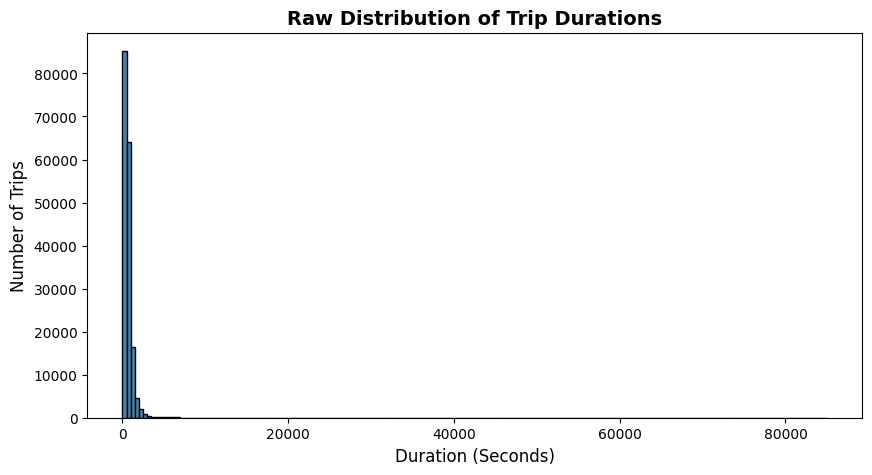

In [3]:
# Plot the raw distribution of duration_sec
plt.figure(figsize=[10, 5])
bins = np.arange(0, df['duration_sec'].max()+500, 500)
plt.hist(data=df, x='duration_sec', bins=bins, color='steelblue', edgecolor='black')
plot_label('Raw Distribution of Trip Durations', 'Duration (Seconds)', 'Number of Trips')
plt.show()

**Observation:** The plot is entirely unreadable because the data is heavily right-skewed. There are extreme outliers (trips lasting over 24 hours) compressing 99% of the data into a single spike on the far left. 

**Data Cleaning:** I will filter the dataset to only include trips under 3,600 seconds (1 hour) to focus on standard, intended usage of the bike-share system.

**Question:** What does the distribution of trip durations look like after removing extreme outliers?

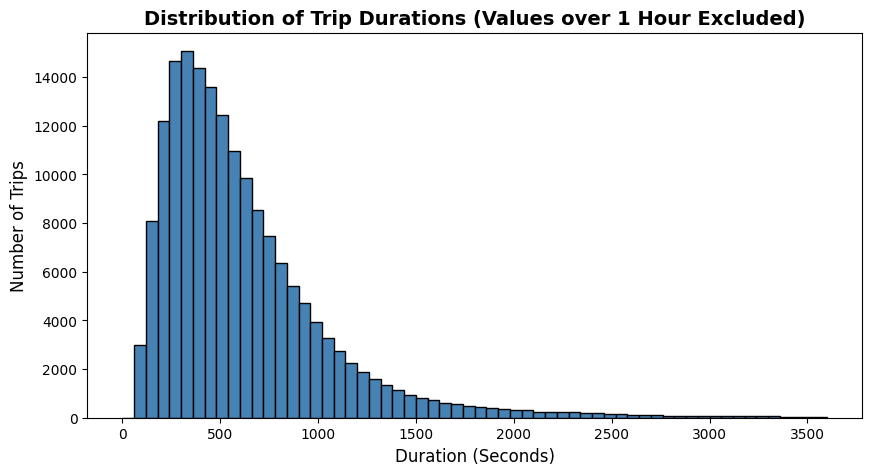

In [4]:
# Filter out trips longer than 1 hour
df = df.query('duration_sec <= 3600')

# Plot the filtered distribution with smaller bin sizes
plt.figure(figsize=[10, 5])
bins = np.arange(0, df['duration_sec'].max()+60, 60)
plt.hist(data=df, x='duration_sec', bins=bins, color='steelblue', edgecolor='black')
plot_label('Distribution of Trip Durations (Values over 1 Hour Excluded)', 'Duration (Seconds)', 'Number of Trips')
plt.show()

**Observation:** With the outliers removed, we can clearly see the distribution is unimodal. The vast majority of trips are short commutes lasting between 300 and 1,000 seconds (5 to 15 minutes).

**Question:** Are there any unusual outliers in the `member_age` variable?

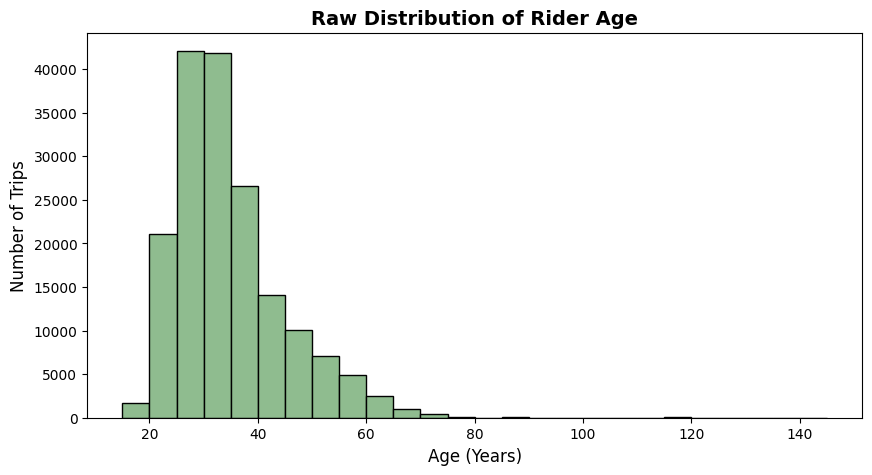

In [5]:
# Plot the raw distribution of member_age
plt.figure(figsize=[10, 5])
bins = np.arange(15, df['member_age'].max()+5, 5)
plt.hist(data=df, x='member_age', bins=bins, color='darkseagreen', edgecolor='black')
plot_label('Raw Distribution of Rider Age', 'Age (Years)', 'Number of Trips')
plt.show()

**Observation:** There are impossible age values extending past 120 and 140 years old. 

**Data Cleaning:** I will filter the dataset to only include riders aged 80 and under to ensure demographic accuracy moving forward.

**Question:** What is the breakdown of user types in the system?

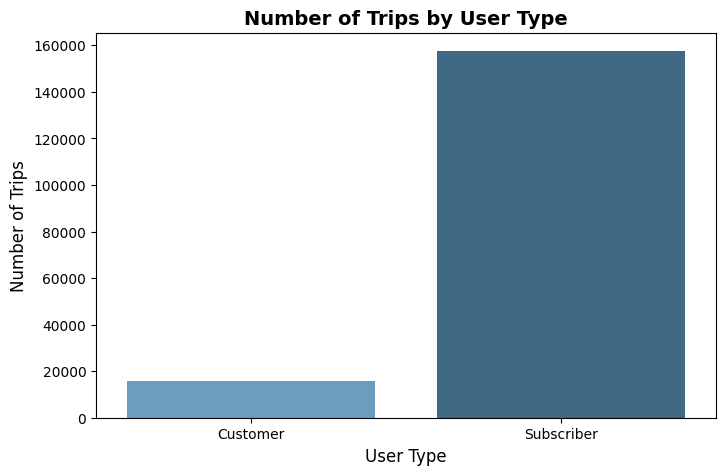

In [6]:
# Filter out riders over the age of 80
df = df.query('member_age <= 80')

# Plot the count of user types
plt.figure(figsize=[8, 5])
sns.countplot(data=df, x='user_type', palette='Blues_d')
plot_label('Number of Trips by User Type', 'User Type', 'Number of Trips')
plt.show()

**Observation:** Subscribers account for the overwhelming majority of total trips compared to casual customers.

## Bivariate Exploration

> In this section, investigate relationships between pairs of variables in your data. Make sure the variables that you cover here have been introduced in some fashion in the previous section (univariate exploration).

**Question:** How does the age of the rider affect the duration of their trip?

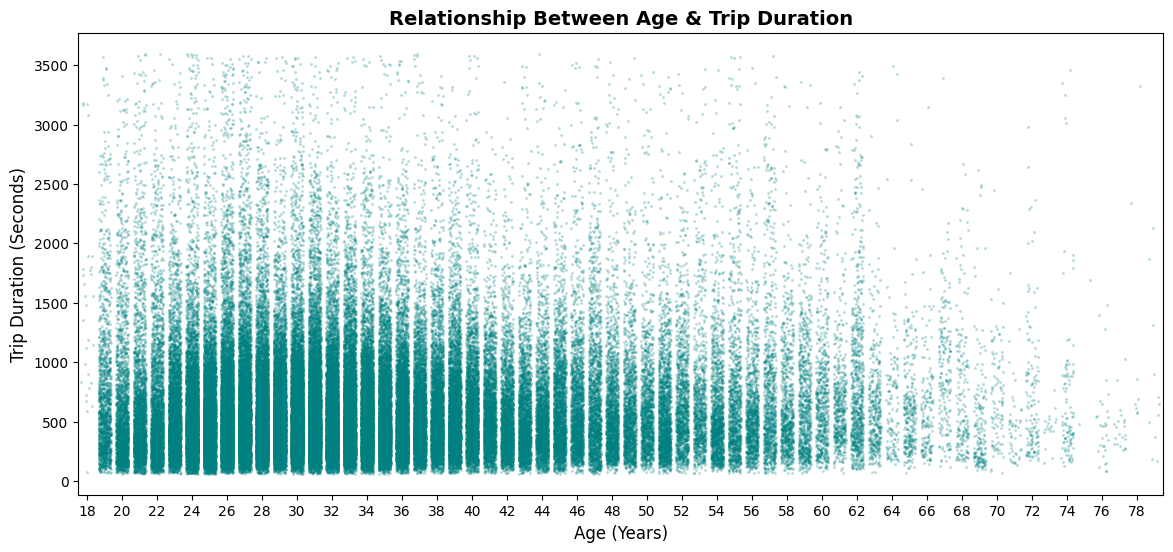

In [7]:
# Create a stripplot to prevent overplotting of discrete integer (age) data
plt.figure(figsize=[14, 6])
sns.stripplot(data=df, x='member_age', y='duration_sec', size=2, jitter=0.35, color='teal', alpha=0.3)
plot_label('Relationship Between Age & Trip Duration', 'Age (Years)', 'Trip Duration (Seconds)')

# Adjust the x-axis ticks so they do not overlap
pos, lab = plt.xticks()
plt.xticks(pos[::2], lab[::2])

plt.show()

**Observation:** By utilizing jitter, we can see the true density of the data. Younger riders (ages 20 to 40) exhibit a massive variance in trip duration, hitting the 1-hour cap frequently. However, as age increases past 60, a natural ceiling emerges, and ride durations strictly narrow toward shorter trips.

**Question:** How does the type of user influence the length of a trip?

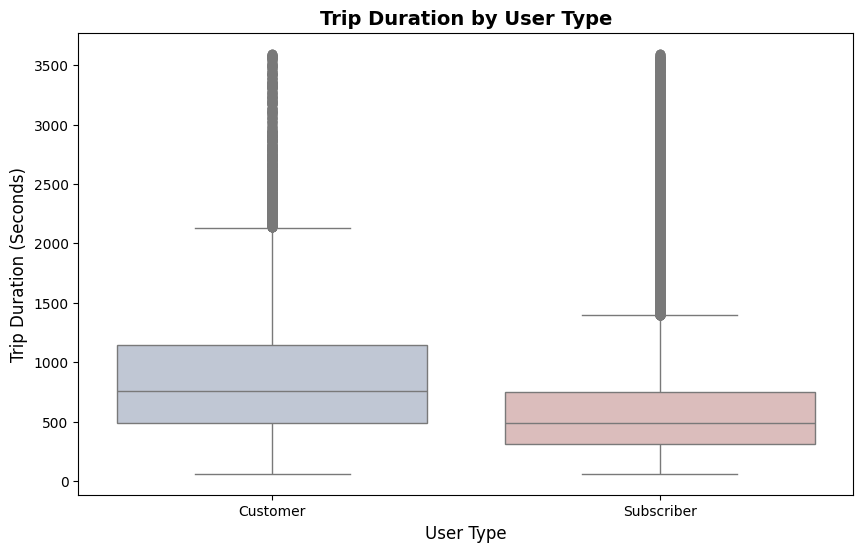

In [8]:
# Boxplot comparing user type to trip duration
plt.figure(figsize=[10, 6])
sns.boxplot(data=df, x='user_type', y='duration_sec', palette='vlag')
plot_label('Trip Duration by User Type', 'User Type', 'Trip Duration (Seconds)')
plt.show()

**Observation:** Despite Subscribers making up the vast majority of total trips, casual Customers have a notably higher median trip duration and a wider interquartile range. This suggests Subscribers use the bikes for highly efficient daily commuting, while Customers may use them for leisure or tourism.

**Question:** Are there any overarching correlations between the numeric variables?

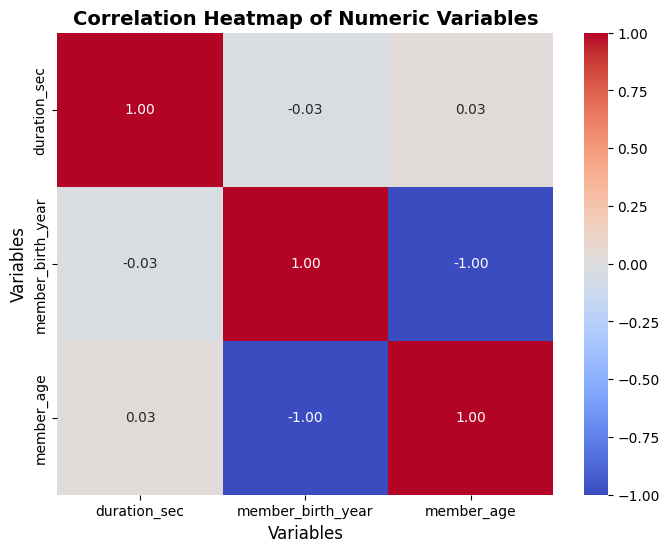

In [9]:
# Generate a correlation matrix for numeric variables
plt.figure(figsize=[8, 6])
numeric_vars = ['duration_sec', 'member_birth_year', 'member_age']
sns.heatmap(df[numeric_vars].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plot_label('Correlation Heatmap of Numeric Variables', 'Variables', 'Variables')
plt.show()

**Observation:** The heatmap confirms a perfect negative correlation between birth year and age (as one was calculated from the other). Neither demographic variable shows a strong linear mathematical correlation with trip duration.

## Multivariate Exploration

> Create plots of three or more variables to investigate your data even
further. Make sure that your investigations are justified, and follow from
your work in the previous sections.


**Question:** Does gender alter the distribution of trip durations across the different user types?

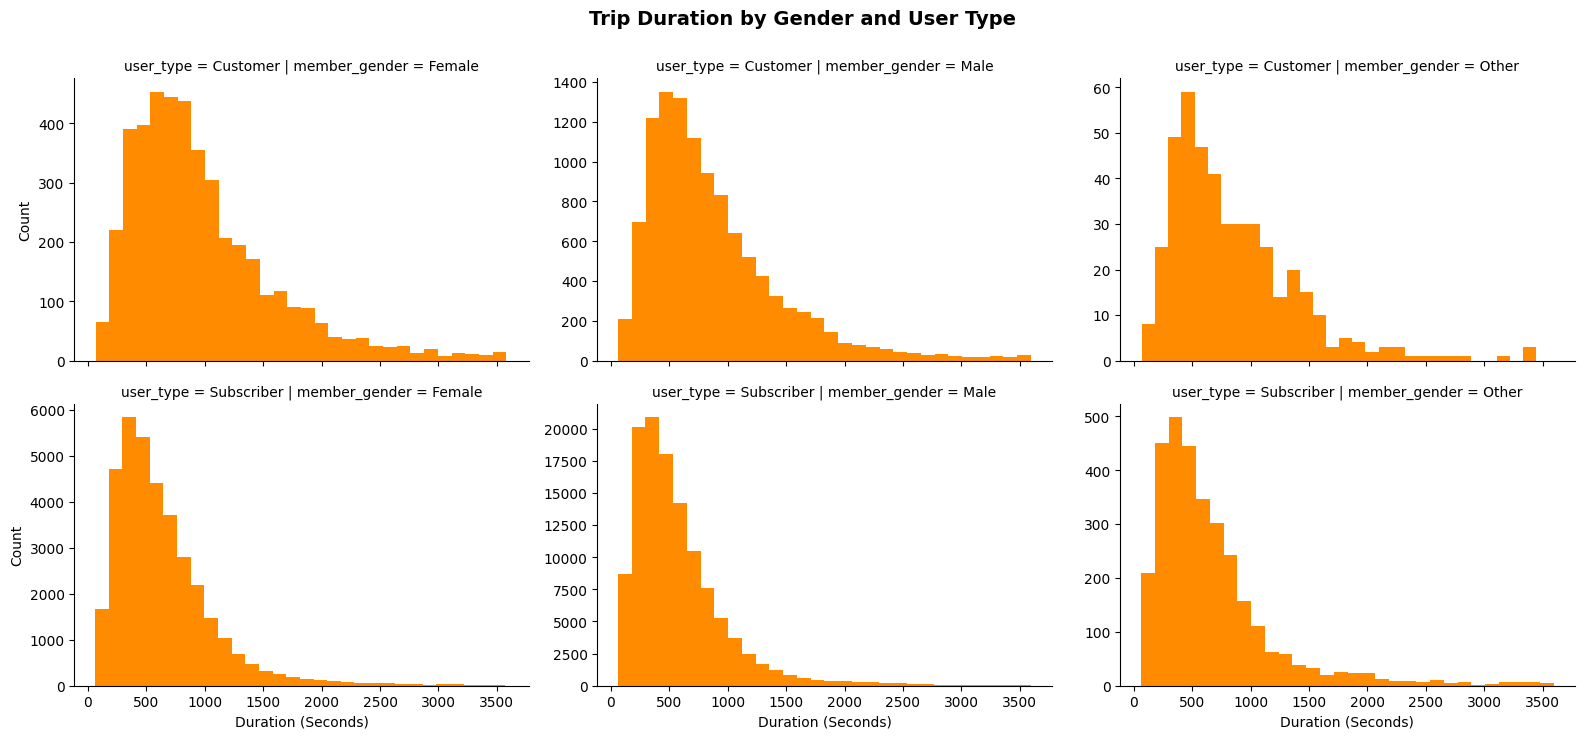

In [10]:
# Create a FacetGrid to view duration by both gender and user type
# sharey=False is used because Subscribers vastly outnumber Customers
g = sns.FacetGrid(data=df, col='member_gender', row='user_type', height=3.5, aspect=1.5, sharey=False)
g.map(plt.hist, 'duration_sec', bins=30, color='darkorange')

# Set labels natively for the grid
g.set_axis_labels('Duration (Seconds)', 'Count')
g.fig.suptitle('Trip Duration by Gender and User Type', y=1.05, fontsize=14, fontweight='bold')
plt.show()

**Observation:** By un-sharing the y-axes, we can compare the shapes of the distributions. Interestingly, the distribution shapes remain remarkably identical across both Males and Females within their respective user type brackets. User type drives behavior far more than gender.

**Question:** How does User Type interact with the established relationship between Rider Age and Trip Duration?

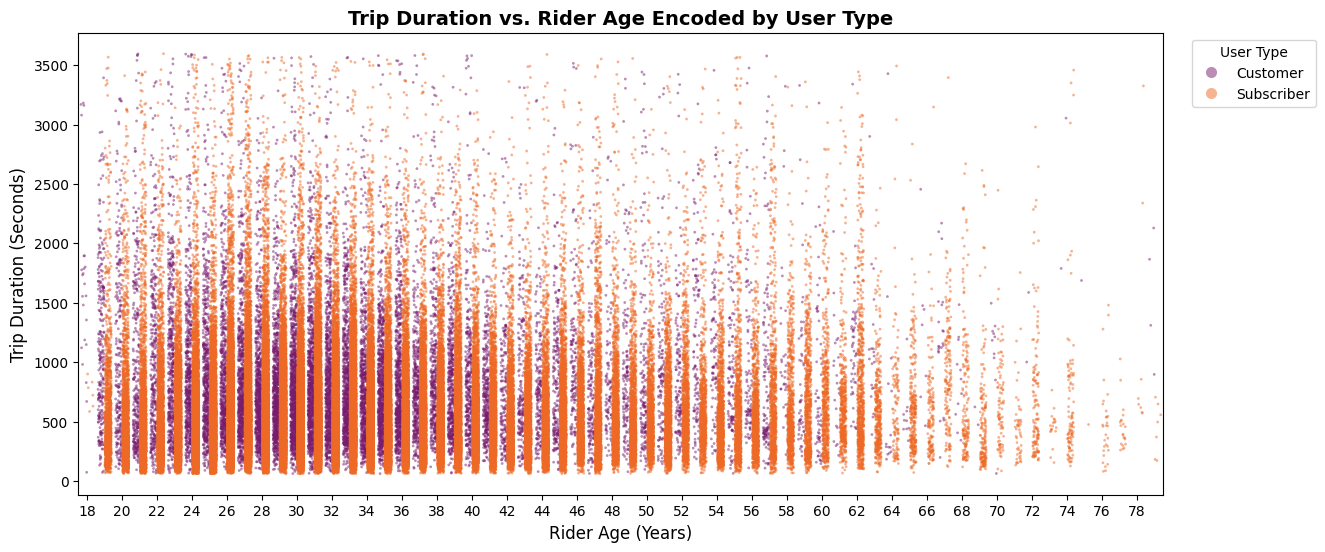

In [11]:
# Use a dodged stripplot to separate the user types clearly at each age integer
plt.figure(figsize=[14, 6])
sns.stripplot(data=df, x='member_age', y='duration_sec', hue='user_type', 
              size=2, jitter=0.35, dodge=True, palette='inferno', alpha=0.5)

plot_label('Trip Duration vs. Rider Age Encoded by User Type', 'Rider Age (Years)', 'Trip Duration (Seconds)')

# Adjust ticks for readability
pos, lab = plt.xticks()
plt.xticks(pos[::2], lab[::2])

# Adjust legend marker size so it can be easily read
plt.legend(title='User Type', markerscale=4, bbox_to_anchor=(1.02, 1), loc='upper left')
plt.show()

**Observation:** This visual ties everything together. Across almost every single age bracket, the Customer data points (darker hues) occupy the higher ranges of the duration y-axis, while Subscriber data points (lighter hues) are densely packed near the bottom. 

### Conclusions
*   **Most trips are short commutes:** The vast majority of trips are under 15 minutes long. Outliers were aggressively filtered out to observe this core system behavior.
*   **Subscribers dominate volume, but Customers dominate duration:** Casual customers consistently take noticeably longer rides on average than daily subscribers.
*   **Age provides a ceiling:** Younger riders exhibit a massive variance in trip durations, taking both short and long trips. However, riders over the age of 60 adhere almost exclusively to shorter trips.